We want to identify employees who are likely to receive a promotion

0 = Employee did NOT get a promotion
1 = Employee DID get a promotion

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv("./HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [51]:
print(df.shape)

(14999, 10)


In [52]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.3 MB
None


In [53]:
X = df[
    [
        "satisfaction_level",
        "last_evaluation",
        "number_project",
        "average_montly_hours",
        "time_spend_company",
        "Work_accident"
    ]
]
Y= df[["promotion_last_5years"]]
X.shape

(14999, 6)

In [54]:
pd.crosstab(
    df["Department"],
    df["promotion_last_5years"],
    normalize="index"
)

promotion_last_5years,0,1
Department,,
IT,0.997555,0.002445
RandD,0.965693,0.034307
accounting,0.981747,0.018253
hr,0.979702,0.020298
management,0.890476,0.109524
marketing,0.949883,0.050117
product_mng,1.000000,0.000000
sales,0.975845,0.024155
support,0.991027,0.008973


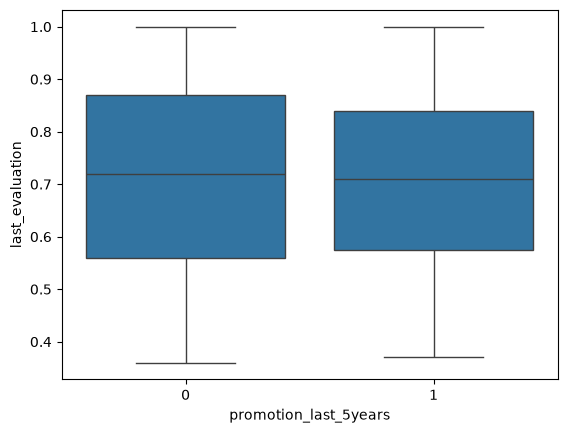

In [55]:
sns.boxplot(
    data=df,
    x="promotion_last_5years",
    y="last_evaluation"
)

plt.show()

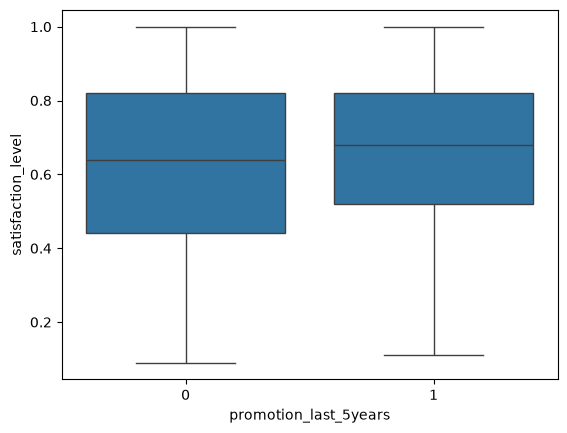

In [56]:
sns.boxplot(
    data=df,
    x="promotion_last_5years",
    y="satisfaction_level"
)

plt.show()

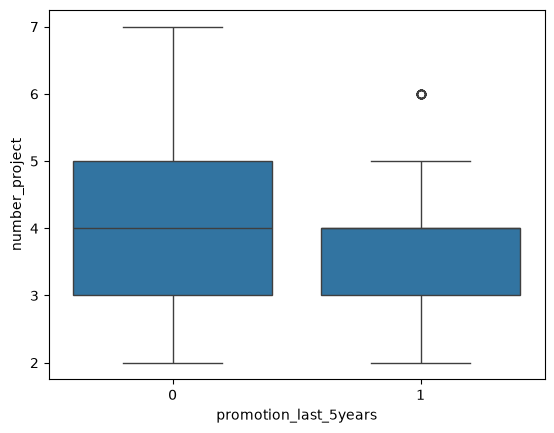

In [57]:
sns.boxplot(
    data=df,
    x="promotion_last_5years",
    y="number_project"
)

plt.show()

In [58]:


from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,random_state=42,test_size=0.2,stratify=Y)

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(X_train)
x_test_scaler = scaler.fit_transform(X_test)

In [60]:
from sklearn.linear_model import LogisticRegression

model =LogisticRegression()
model.fit(x_train_scaler,Y_train)

/opt/anaconda3/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [61]:
y_pred =model.predict(x_test_scaler)

In [67]:
from sklearn.metrics import accuracy_score
print("accuracy",accuracy_score(Y_test,y_pred))

accuracy 0.9786666666666667


In [63]:
from sklearn.metrics import precision_score
print("precision_score",precision_score(Y_test,y_pred))


precision_score 0.0


/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [64]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
print("mean_absolute_error",mean_absolute_error(Y_test,y_pred))
print("mean_squared_error",mean_squared_error(Y_test,y_pred))
mse =mean_squared_error(Y_test,y_pred)
rmse = np.sqrt(mse)

print("rmse",rmse)


r2 = r2_score(
    Y_test,
    y_pred
)

print("r2",r2)


mean_absolute_error 0.021333333333333333
mean_squared_error 0.021333333333333333
rmse 0.1460593486680443
r2 -0.021798365122616126


In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    Y_test,
    y_pred
)

print(cm)

[[2936    0]
 [  64    0]]


In [66]:
from sklearn.metrics import classification_report

print(
    classification_report(
        Y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2936
           1       0.00      0.00      0.00        64

    accuracy                           0.98      3000
   macro avg       0.49      0.50      0.49      3000
weighted avg       0.96      0.98      0.97      3000



/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
